# Survival Analysis Lung Adenocarcinoma

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.plotting import add_at_risk_counts 
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [19]:
# Load data
df = pd.read_excel("Luad_mskcc_2023.xlsx")
df.head()

,Study ID,Patient ID,Sample ID,Adjuvant,Adjuvant Chemotherapy,Adjuvant Immunotherapy,Adjuvant Targeted,Adjuvant Therapy,Adjuvant XRT,Adrenal Met Status (Months),...,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Somatic Status,TGF-Beta Pathway,TMB (nonsynonymous),TP53 Pathway,WNT Pathway
0,luad_mskcc_2023_met_organotropism,P-0000149,P-0000149-T01-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tumor,1,883.0,Metastasis,Female,Matched,No,9.982398,No,No
1,luad_mskcc_2023_met_organotropism,P-0000163,P-0000163-T02-IM3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Tumor,1,439.0,Metastasis,Female,Matched,No,3.327466,Yes,No
2,luad_mskcc_2023_met_organotropism,P-0000208,P-0000208-T01-WES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,Primary,NaN,Matched,NaN,2.933333,NaN,NaN
3,luad_mskcc_2023_met_organotropism,P-0000208,P-0000208-T02-WES,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,NaN,Metastasis,NaN,Matched,NaN,1.600000,NaN,NaN
4,luad_mskcc_2023_met_organotropism,P-0000219,P-0000219-T01-IM3,Yes,Yes,No,No,Yes,Yes,NaN,...,Tumor,1,1033.0,Primary,Female,Matched,Yes,4.436621,No,No


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 94 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Study ID                                      2653 non-null   object 
 1   Patient ID                                    2653 non-null   object 
 2   Sample ID                                     2653 non-null   object 
 3   Adjuvant                                      641 non-null    object 
 4   Adjuvant Chemotherapy                         880 non-null    object 
 5   Adjuvant Immunotherapy                        880 non-null    object 
 6   Adjuvant Targeted                             880 non-null    object 
 7   Adjuvant Therapy                              603 non-null    object 
 8   Adjuvant XRT                                  880 non-null    object 
 9   Adrenal Met Status (Months)                   38 non-null     f

## Preprocessing

In [21]:
columns_needed = [
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Age at Surgery/Biopsy",
    "Sex",
    "Race Category",
    "Tobacco History",
    "TMB (nonsynonymous)",
    "Fraction Genome Altered",
    "Gene Panel",
    "Predominant Histologic Subtype"
]

df = df[columns_needed].copy()

rename_map = {
    "TMB (nonsynonymous)": "TMB_nonsynonymous",
    "Race Category": "Race_Category",
    "Predominant Histologic Subtype": "Predominant_Histologic_Subtype",
    "Gene Panel": "Gene_Panel",
    "Tobacco History": "Tobacco_History",
    "Fraction Genome Altered": "Fraction_Genome_Altered",
    "Age at Surgery/Biopsy": "Age_at_Surgery_Biopsy"
}
df.rename(columns=rename_map, inplace=True)

# Hapus duplikat
print(f"Jumlah duplikat sebelum: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Jumlah duplikat setelah: {df.duplicated().sum()}")

# Hapus baris dengan missing pada target survival
df = df.dropna(subset=['Overall Survival (Months)', 'Overall Survival Status']).copy()

# Hapus baris dengan missing pada semua variabel analisis (complete-case)
df = df.dropna().copy()

print(f"\nData akhir: {df.shape[0]} baris, {df.shape[1]} kolom")

Jumlah duplikat sebelum: 13
Jumlah duplikat setelah: 0

Data akhir: 638 baris, 10 kolom


In [22]:
# Encode status survival
df['event'] = df['Overall Survival Status'].map({'0:LIVING': 0, '1:DECEASED': 1})
df['time'] = df['Overall Survival (Months)']

# HAPUS KOLOM ASLI YANG SUDAH TIDAK DIGUNAKAN
df = df.drop(columns=['Overall Survival Status', 'Overall Survival (Months)'])

# Simpan variabel numerik dan kategorikal
numerical_vars = ['Age_at_Surgery_Biopsy', 'TMB_nonsynonymous', 'Fraction_Genome_Altered']
categorical_vars_encode = ['Sex', 'Race_Category', 'Tobacco_History', 
                           'Gene_Panel', 'Predominant_Histologic_Subtype']

df_encoded = pd.get_dummies(
    df,
    columns=categorical_vars_encode,
    drop_first=True,
    prefix_sep='_'
)

# Simpan daftar kolom kategorikal dummy untuk referensi
dummy_cols = [col for col in df_encoded.columns if any(cat in col for cat in categorical_vars_encode)]

print(f"\nJumlah kolom setelah encoding: {df_encoded.shape[1]}")
print("Kolom dummy (contoh 5):", dummy_cols[:5])

print(f"Data akhir: {df.shape[0]} baris, {df.shape[1]} kolom")


Jumlah kolom setelah encoding: 18
Kolom dummy (contoh 5): ['Sex_Male', 'Race_Category_Black', 'Race_Category_Other', 'Race_Category_Unknown', 'Race_Category_White']
Data akhir: 638 baris, 10 kolom


## Kaplan-Meier

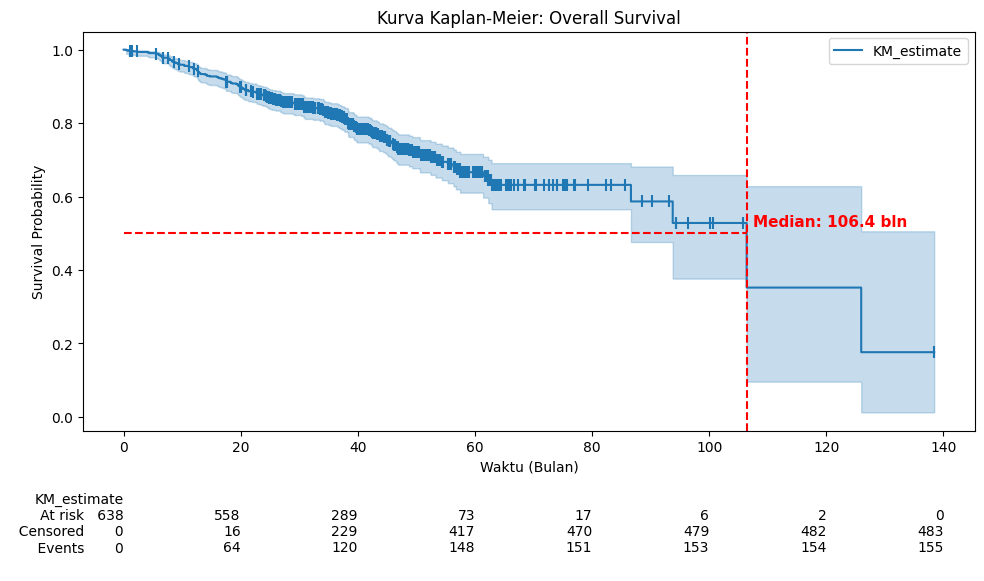


=== Kaplan-Meier & Log-rank: Sex ===


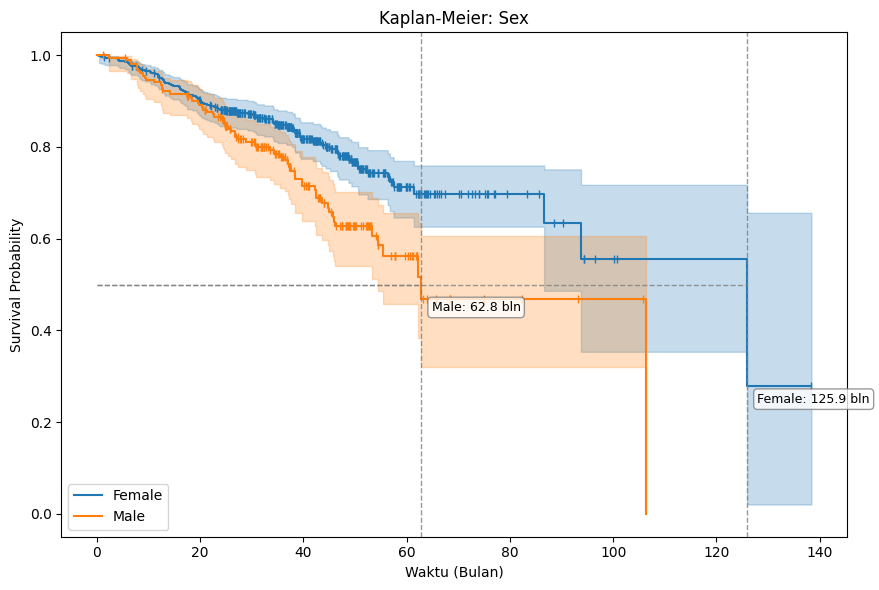

Log-rank p-value: 0.0540

=== Kaplan-Meier & Log-rank: Race_Category ===


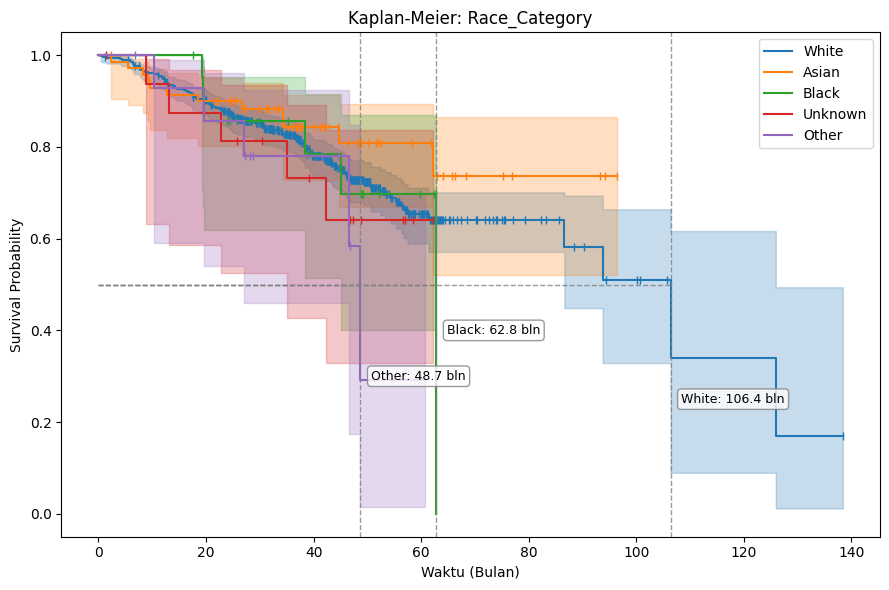

Multivariate Log-rank p-value: 0.4970

=== Kaplan-Meier & Log-rank: Tobacco_History ===


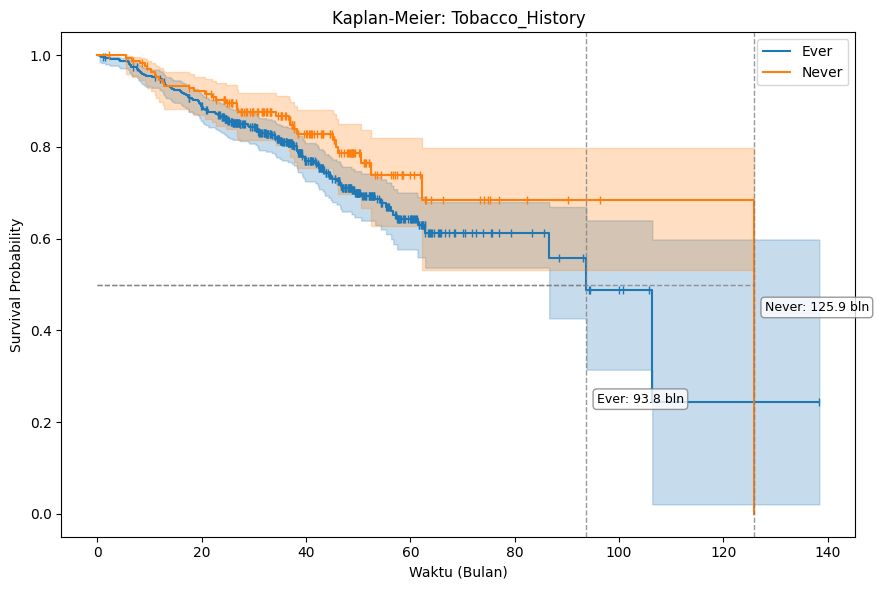

Log-rank p-value: 0.6424

=== Kaplan-Meier & Log-rank: Gene_Panel ===


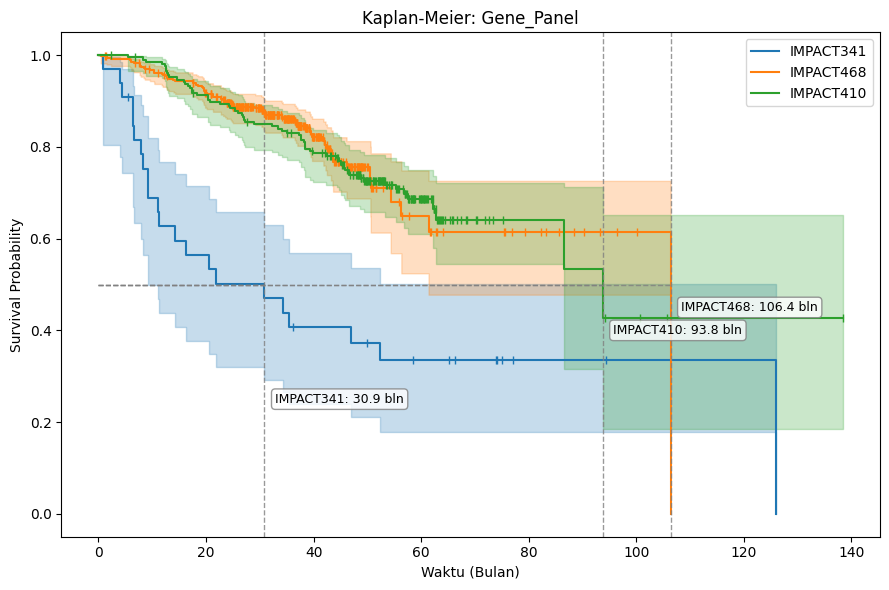

Multivariate Log-rank p-value: 0.0000

=== Kaplan-Meier & Log-rank: Predominant_Histologic_Subtype ===


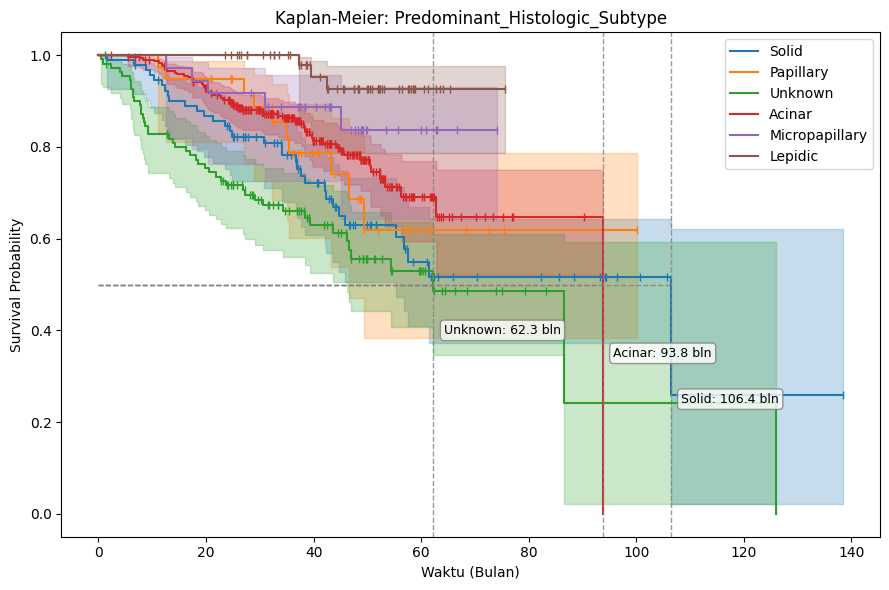

Multivariate Log-rank p-value: 0.0000


In [23]:
# KM Overall Survival
plt.figure(figsize=(10, 6))
kmf = KaplanMeierFitter()
kmf.fit(df['time'], df['event'])
ax = kmf.plot(ci_show=True, show_censors=True, censor_styles={'marker': '|', 'ms': 8, 'mew': 1.5})
median_time = kmf.median_survival_time_
if not np.isnan(median_time):
    # Garis vertikal
    ax.axvline(median_time, color='red', linestyle='--', linewidth=1.5)
    # Garis horizontal dari y=0.5 ke median
    ax.hlines(0.5, 0, median_time, color='red', linestyle='--', linewidth=1.5)
    # Teks nilai median (diperjelas posisi dan format)
    ax.text(median_time + 1, 0.52, f'Median: {median_time:.1f} bln', color='red', fontsize=11, weight='bold')
add_at_risk_counts(kmf, ax=ax)
ax.set_title('Kurva Kaplan-Meier: Overall Survival')
ax.set_xlabel('Waktu (Bulan)')
ax.set_ylabel('Survival Probability')
plt.tight_layout()
plt.show()

# KM per variabel
for var in categorical_vars_encode:
    print(f"\n=== Kaplan-Meier & Log-rank: {var} ===")
    if df[var].nunique() < 2:
        print("Hanya 1 kategori → lewati.")
        continue

    plt.figure(figsize=(9, 6))
    ax = plt.subplot(111)
    groups = df[var].dropna().unique()
    fitted_kms = []
    
    for group in groups:
        mask = df[var] == group
        if mask.sum() < 5:
            continue
        km = KaplanMeierFitter()
        km.fit(df.loc[mask, 'time'], df.loc[mask, 'event'], label=str(group))
        km.plot(
            ax=ax,
            ci_show=True,
            show_censors=True,
            censor_styles={'marker': '|', 'ms': 6, 'mew': 1}
        )
        # Garis median (vertikal + horizontal)
        median_t = km.median_survival_time_
        if not np.isnan(median_t):
            ax.axvline(median_t, linestyle='--', linewidth=1, alpha=0.8, color='gray')
            ax.hlines(0.5, 0, median_t, linestyle='--', linewidth=1, alpha=0.8, color='gray')

            # Atur posisi teks secara dinamis
            # Gunakan y yang berbeda untuk setiap grup (misal: mulai dari 0.45 turun 0.05 per grup)
            # Ini adalah solusi sederhana untuk menghindari tumpang tindih
            y_positions = [0.45, 0.40, 0.35, 0.30, 0.25]  # sesuaikan dengan jumlah grup
            if len(fitted_kms) <= len(y_positions):
                y_pos = y_positions[len(fitted_kms)-1]
            else:
                y_pos = 0.25 - 0.05 * (len(fitted_kms) - len(y_positions))

            # Teks dengan background box dan warna kontras
            text = f'{group}: {median_t:.1f} bln'
            ax.text(
                median_t + 2,  # sedikit lebih jauh dari garis
                y_pos,
                text,
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='gray', alpha=0.8),
                color='black',
                ha='left',
                va='center'
            )
        fitted_kms.append(km)
    
    plt.title(f'Kaplan-Meier: {var}')
    plt.xlabel('Waktu (Bulan)')
    plt.ylabel('Survival Probability')
    plt.tight_layout()
    plt.show()

    # Uji Log-rank
    if df[var].nunique() == 2:
        vals = df[var].unique()
        mask1, mask2 = df[var] == vals[0], df[var] == vals[1]
        test = logrank_test(
            df.loc[mask1, 'time'], df.loc[mask2, 'time'],
            event_A=df.loc[mask1, 'event'], event_B=df.loc[mask2, 'event']
        )
        print(f"Log-rank p-value: {test.p_value:.4f}")
    else:
        test = multivariate_logrank_test(df['time'], df[var], df['event'])
        print(f"Multivariate Log-rank p-value: {test.p_value:.4f}")

In [16]:
print(df_encoded.columns.tolist())

['Age_at_Surgery_Biopsy', 'TMB_nonsynonymous', 'Fraction_Genome_Altered', 'event', 'time', 'Sex_Male', 'Race_Category_Black', 'Race_Category_Other', 'Race_Category_Unknown', 'Race_Category_White', 'Tobacco_History_Never', 'Gene_Panel_IMPACT410', 'Gene_Panel_IMPACT468', 'Predominant_Histologic_Subtype_Lepidic', 'Predominant_Histologic_Subtype_Micropapillary', 'Predominant_Histologic_Subtype_Papillary', 'Predominant_Histologic_Subtype_Solid', 'Predominant_Histologic_Subtype_Unknown']


## Regresi Cox

In [24]:
# Gunakan seluruh df_encoded karena sudah berisi 'time' dan 'event'
cph_df = df_encoded.copy()

cph = CoxPHFitter()
cph.fit(cph_df, duration_col='time', event_col='event')

print("\n=== Hasil Regresi Cox Awal ===")
cph.print_summary()


=== Hasil Regresi Cox Awal ===


<lifelines.CoxPHFitter: fitted with 638 total observations, 483 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 638
number of events observed = 155
   partial log-likelihood = -873.02
         time fit was run = 2025-12-26 04:34:42 UTC

---
                                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                      
Age_at_Surgery_Biopsy                          0.01      1.01      0.01           -0.01            0.03                0.99                1.03
TMB_nonsynonymous                              0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Fraction_Genome_Altered                        1.29      3.63      0.58            0.15            2.43                1.16               11.31
Sex_Male                                       0.47      1.60      0.17            0.14            0.80                1.15                2.23
Race_Category_Black                            0.49      1.63      0.51           -0.51            1.49                0.60                4.46
Race_Category_Other                            0.92      2.50      0.55           -0.16            1.99                0.85                7.32
Race_Category_Unknown                          0.51      1.66      0.55           -0.56            1.58                0.57                4.85
Race_Category_White                            0.17      1.18      0.32           -0.46            0.80                0.63                2.22
Tobacco_History_Never                         -0.50      0.61      0.23           -0.95           -0.04                0.39                0.96
Gene_Panel_IMPACT410                          -1.08      0.34      0.27           -1.62           -0.54                0.20                0.58
Gene_Panel_IMPACT468                          -1.21      0.30      0.27           -1.74           -0.69                0.18                0.50
Predominant_Histologic_Subtype_Lepidic        -1.51      0.22      0.60           -2.68           -0.34                0.07                0.71
Predominant_Histologic_Subtype_Micropapillary -0.54      0.58      0.47           -1.46            0.38                0.23                1.46
Predominant_Histologic_Subtype_Papillary       0.04      1.04      0.35           -0.64            0.72                0.53                2.05
Predominant_Histologic_Subtype_Solid           0.40      1.50      0.23           -0.05            0.86                0.95                2.36
Predominant_Histologic_Subtype_Unknown         0.68      1.98      0.21            0.28            1.09                1.32                2.97

                                               cmp to     z      p  -log2(p)
covariate                                                                   
Age_at_Surgery_Biopsy                            0.00  1.35   0.18      2.50
TMB_nonsynonymous                                0.00  0.25   0.80      0.32
Fraction_Genome_Altered                          0.00  2.22   0.03      5.25
Sex_Male                                         0.00  2.79   0.01      7.55
Race_Category_Black                              0.00  0.96   0.34      1.57
Race_Category_Other                              0.00  1.67   0.09      3.40
Race_Category_Unknown                            0.00  0.93   0.35      1.51
Race_Category_White                              0.00  0.52   0.60      0.73
Tobacco_History_Never                            0.00 -2.14   0.03      4.94
Gene_Panel_IMPACT410                             0.00 -3.94 <0.005     13.61
Gene_Panel_IMPACT468                             0.00 -4.51 <0.005     17.22
Predominant_Histologic_Subtype_Lepidic           

## Uji Asumsi PH

In [25]:
print("\n=== Uji Asumsi Proportional Hazards ===")
cph.check_assumptions(cph_df, p_value_threshold=0.05, show_plots=False)


=== Uji Asumsi Proportional Hazards ===
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 638 total observations, 483 right-censored observations>
         test_name = proportional_hazard_test

---
                                                    test_statistic      p  -log2(p)
Age_at_Surgery_Biopsy                         km              2.14   0.14      2.80
                                              rank            3.65   0.06      4.16
Fraction_Genome_Altered                       km              0.11   0.73      0.44
                                              rank            0.19   0.67      0.59
Gene_Panel_IMPACT410                          km              5.51   0.02      5.72
                                              rank            6.93   0.01      6.89
Gene_Panel_IMPACT468                          km              7.27   0.01      7.16
                                              rank            8.41 <0.005      8.07
Predominant_Histologic_Subtype_Lepidic        km              0.30   0.58      0.78
                                              rank            0.89   0.35      1.53
Predominant_Histologic_Subtype_Micropapillary km              0.40   0.53      0.92
                                              rank            0.43   0.51      0.97
Predominant_Histologic_Subtype_Papillary      km              0.08   0.77      0.37
                                              rank            0.46   0.50      1.01
Predominant_Histologic_Subtype_Solid          km              0.15   0.70      0.51
                                              rank            0.10   0.75      0.42
Predominant_Histologic_Subtype_Unknown        km              3.75   0.05      4.24
                                              rank            6.76   0.01      6.74
Race_Category_Black                           km              1.71   0.19      2.38
                                              rank            2.71   0.10      3.33
Race_Category_Other                           km              2.01   0.16      2.67
                                              rank            3.35   0.07      3.89
Race_Category_Unknown                         km              0.03   0.86      0.21
                                              rank            0.18   0.67      0.57
Race_Category_White                           km              0.76   0.38      1.38
                                              rank            1.72   0.19      2.40
Sex_Male                                      km              1.55   0.21      2.23
                                              rank            1.94   0.16      2.61
TMB_nonsynonymous                             km              0.01   0.93      0.10
                                              rank            0.00   0.98      0.04
Tobacco_History_Never                         km              0.01   0.93      0.10
                                              rank            0.33   0.57      0.81



1. Variable 'Gene_Panel_IMPACT410' failed the non-proportional test: p-value is 0.0085.

   Advice: with so few unique values (only 2), you can include `strata=['Gene_Panel_IMPACT410',
...]` in the call in `.fit`. See documentation in link [E] below.

2. Variable 'Gene_Panel_IMPACT468' failed the non-proportional test: p-value is 0.0037.

   Advice: with so few unique values (only 2), you can include `strata=['Gene_Panel_IMPACT468',
...]` in the call in `.fit`. See documentation in link [E] below.

3. Variable 'Predominant_Histologic_Subtype_Unknown' failed the non-proportional test: p-value is 0.0093.

   Advice: with so few unique values (only 2), you can include
`strata=['Predominant_Histologic_Subtype_Unknown', ...]` in the call in `.fit`. See documentation in
link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assump

[]

## Regresi Cox Stratifikasi


Dimensi data untuk model: (638, 13)
Kolom dalam df_model: ['Age_at_Surgery_Biopsy', 'TMB_nonsynonymous', 'Fraction_Genome_Altered', 'Gene_Panel', 'Predominant_Histologic_Subtype', 'event', 'time', 'Sex_Male', 'Race_Category_Black', 'Race_Category_Other', 'Race_Category_Unknown', 'Race_Category_White', 'Tobacco_History_Never']
Cek kolom strata 'Gene_Panel': Tipe data = object
Cek kolom strata 'Predominant_Histologic_Subtype': Tipe data = object

--- Cek Ukuran Sampel Kombinasi Strata ---
   Gene_Panel Predominant_Histologic_Subtype  counts  events
1   IMPACT341                 Micropapillary       1       0
3   IMPACT341                          Solid       2       0
6   IMPACT410                        Lepidic      29       1
14  IMPACT468                      Papillary      24       1
13  IMPACT468                 Micropapillary      23       1
12  IMPACT468                        Lepidic      32       2
2   IMPACT341                      Papillary       2       2
0   IMPACT341      

model,lifelines.CoxPHFitter
duration col,'time'
event col,'event'
penalizer,0.1
l1 ratio,0.0
strata,"[Gene_Panel, Predominant_Histologic_Subtype]"
baseline estimation,breslow
number of observations,638
number of events observed,155
partial log-likelihood,-518.27
time fit was run,2025-12-26 04:34:49 UTC


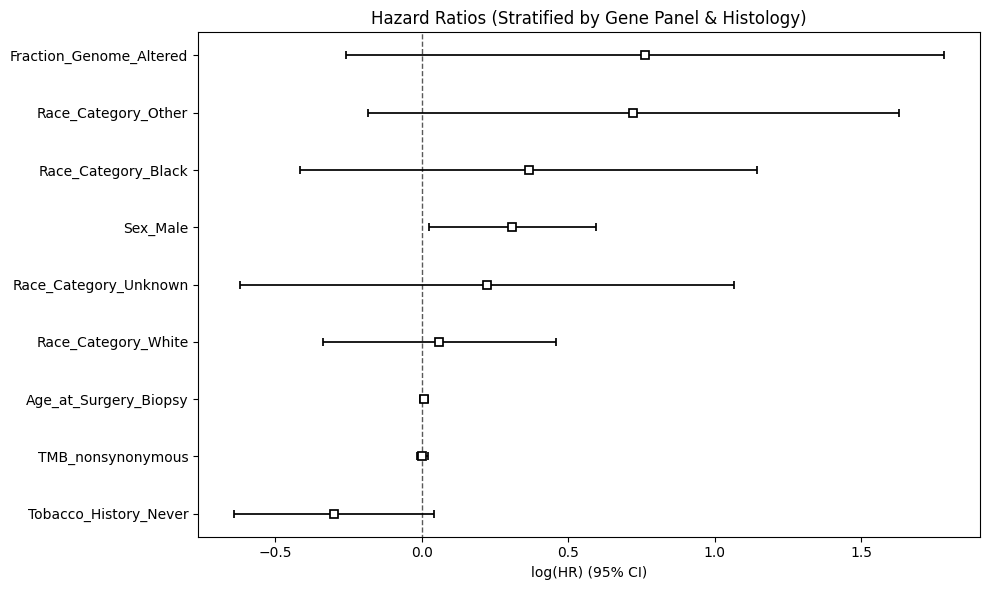


=== Cek Asumsi PH (Post-Stratification) ===
Proportional hazard assumption looks okay.


[]

In [ ]:
# DEFINISI VARIABEL
# Variabel penyebab pelanggaran PH -> AKAN DIJADIKAN STRATA (Jangan di-encode)
vars_for_strata = ['Gene_Panel', 'Predominant_Histologic_Subtype']

# Variabel kategorik lainnya -> AKAN DI-ENCODE (Jadi Dummy)
vars_for_dummy = ['Sex', 'Race_Category', 'Tobacco_History']

# Variabel numerik (Tidak diapa-apakan)
vars_numeric = ['Age_at_Surgery_Biopsy', 'TMB_nonsynonymous', 'Fraction_Genome_Altered']

# SELECTIVE ENCODING
# Hanya melakukan get_dummies pada 'vars_for_dummy'.
# Kolom 'vars_for_strata' dibiarkan tetap string/object.
df_model = pd.get_dummies(
    df,
    columns=vars_for_dummy,
    drop_first=True,  # Menghindari multikolinearitas (dummy trap)
    prefix_sep='_'
)

print(f"\nDimensi data untuk model: {df_model.shape}")
print("Kolom dalam df_model:", df_model.columns.tolist())

# Pastikan kolom strata masih ada dan bertipe object/string
for col in vars_for_strata:
    print(f"Cek kolom strata '{col}': Tipe data = {df_model[col].dtype}")
    # Jika tipe category, ubah ke string/object agar aman di lifelines
    if df_model[col].dtype.name == 'category':
        df_model[col] = df_model[col].astype(str)

# UKURAN SAMPEL PER STRATA
# Stratifikasi memecah data menjadi kotak-kotak kecil (Gene Panel x Histology).
# Jika ada kotak yang kosong atau isinya < 2 event, model akan error/tidak konvergen.
print("\n--- Cek Ukuran Sampel Kombinasi Strata ---")
# Menghitung jumlah sampel di setiap kombinasi
strata_counts = df_model.groupby(vars_for_strata).size().reset_index(name='counts')
# Menghitung jumlah event di setiap kombinasi
strata_events = df_model.groupby(vars_for_strata)['event'].sum().reset_index(name='events')

# Gabungkan info
strata_check = pd.merge(strata_counts, strata_events, on=vars_for_strata)
print(strata_check.sort_values('events'))

# AUTO-GROUPING
# Jika ada kombinasi strata dengan event < 3, kita gabungkan kategori Histology kecil ke 'Other'
min_event_threshold = 3
problematic_mask = strata_check['events'] < min_event_threshold

if problematic_mask.any():
    print(f"\n[PERINGATAN] Ada kombinasi strata dengan event < {min_event_threshold}.")
    print("Melakukan penggabungan kategori Histology kecil menjadi 'Other_Subtype'...")
    
    # Hitung total histori histology
    hist_counts = df['Predominant_Histologic_Subtype'].value_counts()
    # Simpan kategori besar saja (misal yang > 20 sampel)
    major_histology = hist_counts[hist_counts > 20].index.tolist()
    
    # Replace kategori kecil
    df_model['Predominant_Histologic_Subtype'] = df_model['Predominant_Histologic_Subtype'].apply(
        lambda x: x if x in major_histology else 'Other_Subtype'
    )
    print("Kategori Histology setelah grouping:", df_model['Predominant_Histologic_Subtype'].unique())

# FITTING MODEL STRATIFIED COX
cph_strat = CoxPHFitter(penalizer=0.1) 

print("\n--- Memulai Fitting Model Stratifikasi ---")
try:
    cph_strat.fit(
        df_model,
        duration_col='time',
        event_col='event',
        strata=vars_for_strata,  
        formula=None             # Biarkan None, lifelines akan pakai semua sisa kolom
    )

    print("\n=== HASIL REGRESI COX TERSTRATIFIKASI ===")
    cph_strat.print_summary()

    # Visualisasi Koefisien (Hazard Ratio)
    plt.figure(figsize=(10, 6))
    cph_strat.plot()
    plt.title("Hazard Ratios (Stratified by Gene Panel & Histology)")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[ERROR] Model Gagal: {e}")
    print("Saran: Cek output 'Safety Check' di atas. Mungkin perlu grouping kategori Gene Panel juga.")

# CEK ASUMSI PH SETELAH STRATIFIKASI
print("\n=== Cek Asumsi PH (Post-Stratification) ===")
# Note: Variabel strata tidak akan diuji lagi (karena sudah jadi baseline)
# Kita hanya menguji variabel kovariat (Age, Sex, TMB, dll)
cph_strat.check_assumptions(df_model, p_value_threshold=0.05, show_plots=False)